## Notebook 4: Threshold Tuning and SQL Layer

Coming out of the model comparison: plain Random Forest with class_weight='balanced' was the winner, 92% precision, 81% recall, F1 of 0.86, beating both the Logistic Regression baseline and the SMOTE version.

So far every model has used the default rule: if it's more than 50% confident something is fraud, call it fraud. That 50% cutoff is completely arbitrary, though. In this notebook I'll look at the full range of possible cutoffs, pick one deliberately based on a business tradeoff I can actually justify, and lock in a final model. Then, since the job I'm targeting wants SQL specifically, I'll load the data into a small SQL database and run a few queries against it instead of sticking to pandas.

### Step 6: Threshold Tuning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Same preprocessing as before (see notebooks 2 and 3 for the full explanation)
df = pd.read_csv('../data/creditcard.csv')
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)  # features
y = df['Class']               # target (0 = normal, 1 = fraud)

# Same train/test split as before (same random_state=42 and stratify=y) so results stay comparable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain the winning model from Notebook 3 (Random Forest with class_weight='balanced')
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

### Step 6.1 - Get probabilities instead of hard labels

In [2]:
# predict_proba returns two columns: [probability of Normal, probability of Fraud]
# We only want the second column - the model's confidence that each
# transaction IS fraud, as a number between 0 and 1
y_probs = rf_model.predict_proba(X_test)[:, 1]

.predict() gives a hard yes/no answer using an invisible default: if the model's fraud probability is above 0.5, call it fraud. But 0.5 is just a default, nothing forces me to use it. .predict_proba() instead gives me the model's raw confidence score for every transaction, something like "I think this one is 73% likely to be fraud." Having those raw scores means I can pick my own cutoff deliberately, based on the tradeoff I actually want, instead of just accepting whatever scikit-learn defaults to.

### Step 6.2 - Precision-recall curve

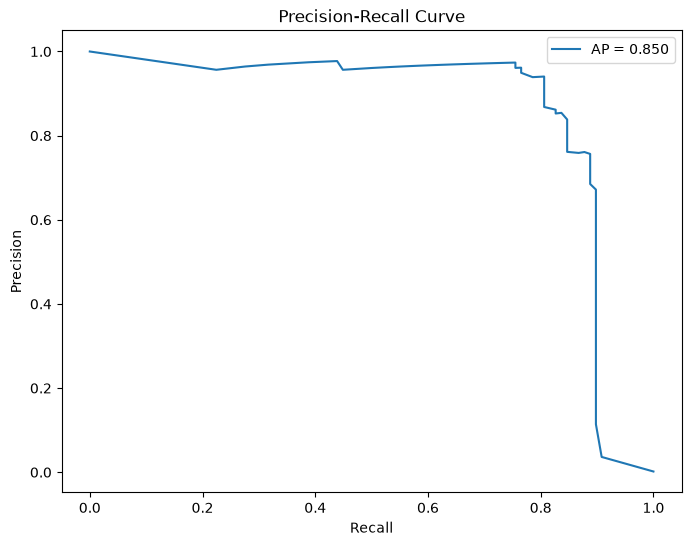

In [3]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# This function tries many possible thresholds and, at each one, calculates
# what precision and recall would be if we used that threshold as the cutoff
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# A single summary number (0 to 1) for how good the model is across
# ALL possible thresholds at once - higher is better
ap_score = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig('../dashboard/precision_recall_curve.png')
plt.show()

Every point on this curve is one possible threshold choice. Moving right along it (higher recall) means catching more fraud, but precision drops as I do. That tradeoff is now a shape instead of just two numbers. A curve that stays high near the top as it moves right is a strong model. One that collapses quickly toward the bottom-right means precision falls apart the moment you try to catch more fraud.

AP (average precision) is just a single number summarizing the whole curve, roughly the area underneath it. Closer to 1.0 means a stronger model across every possible threshold, not just the default 0.5 one.

AP score came out to 0.850.

Looking at the shape: precision stays high, around 0.95-1.0, all the way out to roughly recall = 0.75-0.8. So the model can catch up to ~75-80% of fraud while still being right the vast majority of the time it flags something. Past that, the curve drops sharply. Pushing recall higher than ~0.8 gets expensive fast, and precision basically collapses toward 0 by the time recall approaches 1.0.

Practically, that tells me there's a sweet spot somewhere in the 0-0.8 recall range where I can gain a lot of fraud-catching ability without giving up much precision. Past that, every extra bit of recall costs a lot more in false alarms. This is exactly what threshold tuning is for. Picking a point on this curve on purpose, instead of just taking whatever the default 0.5 cutoff happens to land on.

### Step 6.3 - Pick a threshold based on a stated tradeoff

In [4]:
# Business goal: catch at least 90% of fraud cases (recall >= 0.90),
# while keeping precision as high as possible given that constraint
target_recall = 0.90

# recalls[:-1] drops the last value because precision_recall_curve adds
# one extra endpoint (recall=0, precision=1) that doesn't correspond to
# a real threshold - we exclude it to keep recalls and thresholds aligned
valid_idx = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    # Among all thresholds that hit at least 90% recall, pick the LAST one -
    # since recall decreases as threshold increases, the last valid index
    # is the highest threshold (and therefore highest precision) that still
    # meets our recall requirement
    best_idx = valid_idx[-1]
    chosen_threshold = thresholds[best_idx]
    print(f"Threshold: {chosen_threshold:.4f}")
    print(f"At this threshold - Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")
else:
    print(f"No threshold achieves recall >= {target_recall}")

Threshold: 0.0100
At this threshold - Precision: 0.036, Recall: 0.908


In fraud detection, missing real fraud (a false negative) is usually more costly to the business than a false alarm. A false alarm just means a human double-checks a legitimate transaction, but a missed fraud case means real financial loss goes undetected. So I set a floor of catching at least 90% of fraud, and asked: given that floor, what's the best precision I can still get?

The code itself is pretty simple. precision_recall_curve already calculated precision and recall at every possible threshold, so I'm just filtering down to the ones where recall is 0.90 or higher, then taking the highest threshold among those, since higher thresholds are stricter, which should push precision back up as far as it can go while still meeting the recall floor.

Result at target_recall = 0.90: threshold 0.0100, precision 0.036 (3.6%), recall 0.908 (90.8%).

To catch 90%+ of fraud, the threshold has to drop all the way down to 0.01, meaning any transaction the model thinks has even a 1% chance of being fraud gets flagged. That's an extremely loose bar, and it shows: only 3.6% of flagged transactions were actually fraud at this setting, which is nearly as bad as the original Logistic Regression baseline (6%).

This actually lines up with what the PR curve shape already showed. It stayed high and flat up to about recall 0.75-0.8, then fell off a cliff. A 90% recall target lands well past that cliff, right in the zone where precision has already collapsed.

In [5]:
# Try a more achievable target, informed by where the curve holds up well
target_recall = 0.80

valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[-1]
    chosen_threshold = thresholds[best_idx]
    print(f"Threshold: {chosen_threshold:.4f}")
    print(f"At this threshold - Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")

Threshold: 0.5700
At this threshold - Precision: 0.940, Recall: 0.806


The 90% target pushed the model past the point where the precision-recall curve actually holds up, landing on an unusable 3.6% precision. Since the curve stays strong up to roughly recall 0.75-0.8, I figured targeting 0.80 should land in, or right at the edge of, that sweet spot, and give a much more realistic tradeoff. This is basically the whole point of plotting the curve before picking a target. 90% sounded reasonable in the abstract, but the data showed it wasn't actually a good operating point for this model.

Result at target_recall = 0.80: threshold 0.5700, precision 0.940 (94%), recall 0.806 (80.6%).

By requiring the model to be at least 57% confident before flagging something as fraud, instead of the default 50%, I get a model that catches about 81% of real fraud while being right 94% of the time it raises an alarm. Compare that to the 90%-recall attempt, which only hit 3.6% precision. A small, deliberate pullback in recall (90% down to 81%) bought a massive gain in precision (3.6% up to 94%). That's a far more workable tradeoff. A review team acting on these flags would rarely be chasing false alarms.

One thing I found interesting: this threshold (0.57) actually ends up higher than the model's default of 0.50, meaning the optimal operating point here is to be slightly more conservative than scikit-learn's default, not less. Worth remembering that the default 0.5 threshold isn't automatically the right call. It just happened to land close to ideal here, mostly because my target (0.80 recall) sits near where 0.57 naturally falls on the curve.

### Step 6.4 - Apply the chosen threshold and get the final confusion

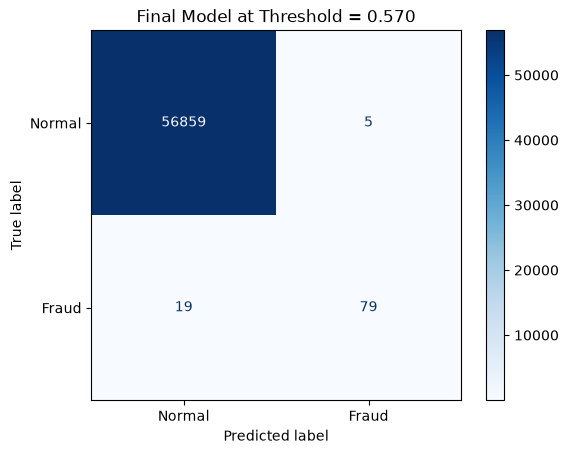

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Instead of using .predict() (which uses the default 0.5 cutoff),
# manually apply our chosen threshold to the raw probabilities:
# if the model's fraud probability is >= 0.57, call it fraud (1), otherwise normal (0)
y_pred_final = (y_probs >= chosen_threshold).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title(f'Final Model at Threshold = {chosen_threshold:.3f}')
plt.savefig('../dashboard/final_confusion_matrix.png')
plt.show()

.predict() always uses the hardcoded 0.5 cutoff internally, there's no built-in way to tell it "use 0.57 instead." So I go back to the raw probabilities from earlier (y_probs) and apply my own comparison: anything >= chosen_threshold becomes True/False, and .astype(int) converts that to 1/0 to match the Class label format.

What I'm expecting to see in the confusion matrix: roughly 79 fraud cases correctly caught (bottom-right), around 19 missed (bottom-left), a small handful of false alarms (top-right, maybe ~5), and the vast majority of the ~56,864 normal transactions correctly left alone (top-left).

**Final threshold decision**

I went with a threshold of 0.57 (recall about 81%, precision about 94%) because in fraud detection, a missed fraud case costs the business real money, while a false alarm only costs a reviewer a few minutes double-checking a legitimate transaction. I tried a stricter 90%-recall target first, but it collapsed precision to under 4%, way too many false alarms to be usable. This threshold is the best balance the model's precision-recall curve actually supports.

### Step 7: SQL Layer

In [7]:
import sqlite3

# Connect to (or create) a SQLite database file - this creates an actual
# .db file on disk that behaves like a real lightweight SQL database
conn = sqlite3.connect('../data/fraud.db')

# Write the dataframe into a SQL table called "transactions".
# if_exists='replace' means re-running this cell won't create duplicates -
# it just overwrites the table fresh each time
df.to_sql('transactions', conn, if_exists='replace', index=False)

# Query 1: basic aggregation - average scaled amount per class
query1 = """
SELECT
    Class,
    COUNT(*) as transaction_count,
    ROUND(AVG(Amount_scaled), 4) as avg_amount_scaled
FROM transactions
GROUP BY Class
"""
result1 = pd.read_sql(query1, conn)
print("Query 1: Transaction count and avg amount by class")
print(result1)

Query 1: Transaction count and avg amount by class
   Class  transaction_count  avg_amount_scaled
0      0             284315            -0.0002
1      1                492             0.1354


sqlite3 lets Python talk to a real SQL database without needing a separate database server. The whole thing lives in one .db file. df.to_sql(...) copies the dataframe into a SQL table, so from here I can write actual SELECT queries against it instead of only using pandas methods. This is mostly to demonstrate I can work with data through SQL directly, since that's a skill the job posting called out specifically.

Query 1 groups all transactions by Class and, for each group, counts the rows and calculates the average scaled transaction amount. ROUND(..., 4) just keeps it to 4 decimal places for readability.

In [8]:
# Query 2: how many high-value transactions are fraud vs normal?
# (using the ORIGINAL Amount would be more intuitive, but we dropped it -
# this uses the scaled version; positive Amount_scaled roughly means "above average")
query2 = """
SELECT
    Class,
    COUNT(*) as high_value_count
FROM transactions
WHERE Amount_scaled > 1.0
GROUP BY Class
"""
result2 = pd.read_sql(query2, conn)
print("\nQuery 2: High-value transaction counts by class")
print(result2)

# Query 3: fraud rate by broad time period (using Time_scaled to split into two halves)
query3 = """
SELECT
    CASE WHEN Time_scaled < 0 THEN 'First Half' ELSE 'Second Half' END as time_period,
    Class,
    COUNT(*) as count
FROM transactions
GROUP BY time_period, Class
"""
result3 = pd.read_sql(query3, conn)
print("\nQuery 3: Fraud counts by time period")
print(result3)

conn.close()  # always close the connection when you're done with it


Query 2: High-value transaction counts by class
   Class  high_value_count
0      0             15658
1      1                52

Query 3: Fraud counts by time period
   time_period  Class   count
0   First Half      0  150837
1   First Half      1     322
2  Second Half      0  133478
3  Second Half      1     170


Query 2 filters down to transactions where the scaled amount is above 1.0 (meaningfully above average) and counts how many of those are fraud vs. normal. A simple WHERE combined with GROUP BY.

Query 3 uses a CASE WHEN, SQL's version of an if/else, to bucket transactions into "First Half" or "Second Half" of the time range, then counts fraud vs. normal within each bucket. A slightly more advanced pattern (conditional logic inside a query) without overdoing it.

I close the connection afterward because database connections use system resources, and leaving them open unnecessarily is bad practice, especially in a notebook I'll rerun a bunch of times.

**Query 1, average amount by class:** normal transactions average almost exactly 0 on the scaled amount (-0.0002, basically the dataset average, since scaling centers everything around 0 by design). Fraud transactions average 0.1354, meaningfully above the overall average. That's a nice numeric confirmation of what the boxplot in notebook 1 already hinted at: fraud tends to skew toward a somewhat higher typical amount than normal, even though both classes still have plenty of low-amount transactions.

**Query 2, high-value transactions:** out of 15,710 total high-value transactions (more than 1 standard deviation above average), only 52 were fraud, about 0.33%. That's roughly double the overall fraud rate of 0.17%, so high-value transactions are somewhat more likely to be fraud than average, but they're still overwhelmingly (99.67%) legitimate. Worth being honest about that. "High amount" is a weak signal on its own, not a reliable fraud indicator by itself.

**Query 3, fraud by time period:** the first half of the time range had 322 fraud cases out of 151,159 transactions (~0.213%), and the second half had 170 out of 133,648 (~0.127%). So fraud was somewhat more concentrated earlier in the dataset's time window. That said, Time is just seconds elapsed with no calendar or clock context, no day-of-week or hour-of-day info, so I can't really say why without more context. I'll leave this as an observation rather than draw a strong conclusion from it.

### Step 9 — Tableau dashboard

### Step 9.1 — Get your data ready

In [9]:
import pandas as pd

# Export the final confusion matrix values as a simple table
confusion_data = pd.DataFrame({
    'Actual': ['Normal', 'Normal', 'Fraud', 'Fraud'],
    'Predicted': ['Normal', 'Fraud', 'Normal', 'Fraud'],
    'Count': [56859, 5, 19, 79]  # from your final confusion matrix
})
confusion_data.to_csv('../dashboard/confusion_matrix_data.csv', index=False)

# Export class distribution for the imbalance chart
class_distribution = pd.DataFrame({
    'Class': ['Normal', 'Fraud'],
    'Count': [284315, 492]
})
class_distribution.to_csv('../dashboard/class_distribution.csv', index=False)

print("Exported!")

Exported!
